In [1]:
import sys
import os
import polars as pl
import numpy as np
# Add the project root directory to PYTHONPATH
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, project_root)

# Import necessary modules
import groundinsight as gi
from groundinsight.models.core_models import BusType, BranchType, ComplexNumber

In [2]:
#Test the Setting of mesh strucutre with multiple cables 

rho = 100
f = 50
# Create a network
net = gi.create_network(name="MyTestNetwork", frequencies=[f])
net.description = "CIRED example Network"

bus_type = BusType(
    name="BusTypeFormulaTest",
    description="Example bus type with parameters",
    system_type="Grounded",
    voltage_level=20,
    impedance_formula="0.01201149 * rho + 0.00024195 * f - 0.00000034 * rho*f + 0.01444725 + 1j * (-0.00003812 * rho + 0.00030091 * f + 0.00000089*rho*f + 0.01997045)",
)

bus_type_uw = BusType(
    name="BusTypeFormulaTestUW",
    description="Example bus type with parameters",
    system_type="Grounded",
    voltage_level=20,
    impedance_formula="0.2"
    )

self_impedance_formula = "(0.24/1000 + (2*pi*f * 4*pi*10**(-7) / 8) + 1j * (2*pi*f * 4*pi*10**(-7) / (2 * pi)) * log((1.8514 / sqrt(2 * pi * f * 4*pi*10**(-7) / rho)) / (0.040**2 * 0.035)**(1/3)))*l"
mutual_impedance_formula = "((2*pi*f * 4*pi*10**(-7) / 8) + 1j * (2*pi*f * 4*pi*10**(-7) / (2 * pi)) * log((1.8514 / sqrt(2 * pi * f * 4*pi*10**(-7) / rho)) / (0.040**2 * 0.035)**(1/3)))*l"

branch_type = BranchType(
    name="TestBranchType",
    description="A test branch type",
    grounding_conductor=True,
    self_impedance_formula=self_impedance_formula,
    mutual_impedance_formula=mutual_impedance_formula
)

branch_ohl = BranchType(
    name="OHLine",
    description="An overhead line",
    grounding_conductor=False,
    self_impedance_formula="NaN",
    mutual_impedance_formula="NaN"
)

number_buses = 5
#create buses with a for loop
for i in range(1, number_buses):
    gi.create_bus(name=f"bus{i}", type=bus_type, network=net, specific_earth_resistance=rho)

gi.create_bus(name="bus5", type=bus_type_uw, network=net, specific_earth_resistance=rho)
#create branch 
#defining a line length of each branch
line_length = 1000

#create branches
gi.create_branch(name=f"branch12", type=branch_type, from_bus=f"bus1", to_bus=f"bus2", length=line_length, specific_earth_resistance=rho, network=net, parallel_coefficient=1)
gi.create_branch(name=f"branch23", type=branch_type, from_bus=f"bus2", to_bus=f"bus3", length=line_length, specific_earth_resistance=rho, network=net, parallel_coefficient=1)
gi.create_branch(name=f"branch34", type=branch_type, from_bus=f"bus3", to_bus=f"bus4", length=line_length, specific_earth_resistance=rho, network=net, parallel_coefficient=1)
gi.create_branch(name=f"branch52", type=branch_type, from_bus=f"bus5", to_bus=f"bus2", length=line_length, specific_earth_resistance=rho, network=net, parallel_coefficient=1)
#gi.create_branch(name=f"branch14", type=branch_type, from_bus=f"bus1", to_bus=f"bus4", length=line_length, specific_earth_resistance=rho, network=net, parallel_coefficient=1)
#create a faults
fault_scaling = {f:1}

gi.create_fault(name=f"fault", bus=f"bus3", description="A fault at bus {i}", scalings=fault_scaling, network=net)



#soruce currents
source_values = {f:60}

#add a source at bus1
#source = gi.create_source(name="source1", bus="bus1", values=source_values, network=net)

#add a source at bus4
source = gi.create_source(name="source", bus="bus5", values=source_values, network=net)

#define the paths of the network
gi.create_paths(network=net)

gi.run_fault(net, fault_name=f"fault")


all_imp = net.res_all_impedances()
all_imp = all_imp.filter(pl.col("frequency_Hz") == f)

all_imp #--> bus2 and bus3 are incorrect because of the additional branch, analyze the paths

for path_name, path in net.paths.items():
    print(f"Path: {path_name}")
    print(f"Source name: {path.source}")
    for segment in path.segments:
        print(segment)


Path: path_1
Source name: source
Branch(name=branch52, from=bus5, to=bus2)
Branch(name=branch23, from=bus2, to=bus3)


In [3]:
#Test the Setting of mesh strucutre with multiple cables 

rho = 100

# Create a network
net = gi.create_network(name="MyTestNetwork", frequencies=[50, 250, 350])
net.description = "CIRED example Network"

bus_type = BusType(
    name="BusTypeFormulaTest",
    description="Example bus type with parameters",
    system_type="Grounded",
    voltage_level=20,
    impedance_formula="0.01201149 * rho + 0.00024195 * f - 0.00000034 * rho*f + 0.01444725 + 1j * (-0.00003812 * rho + 0.00030091 * f + 0.00000089*rho*f + 0.01997045)",
)

bus_type_uw = BusType(
    name="BusTypeFormulaTestUW",
    description="Example bus type with parameters",
    system_type="Grounded",
    voltage_level=20,
    impedance_formula="0.2"
    )

self_impedance_formula = "(0.24/1000 + (2*pi*f * 4*pi*10**(-7) / 8) + 1j * (2*pi*f * 4*pi*10**(-7) / (2 * pi)) * log((1.8514 / sqrt(2 * pi * f * 4*pi*10**(-7) / rho)) / (0.040**2 * 0.035)**(1/3)))*l"
mutual_impedance_formula = "((2*pi*f * 4*pi*10**(-7) / 8) + 1j * (2*pi*f * 4*pi*10**(-7) / (2 * pi)) * log((1.8514 / sqrt(2 * pi * f * 4*pi*10**(-7) / rho)) / (0.040**2 * 0.035)**(1/3)))*l"

branch_type = BranchType(
    name="TestBranchType",
    description="A test branch type",
    grounding_conductor=True,
    self_impedance_formula=self_impedance_formula,
    mutual_impedance_formula=mutual_impedance_formula
)

branch_ohl = BranchType(
    name="OHLine",
    description="An overhead line",
    grounding_conductor=False,
    self_impedance_formula="NaN",
    mutual_impedance_formula="NaN"
)

number_buses = 5
#create buses with a for loop
for i in range(1, number_buses):
    gi.create_bus(name=f"bus{i}", type=bus_type, network=net, specific_earth_resistance=rho)


#create branch 
#defining a line length of each branch
line_length = 1000

#create bracnches with a for loop
for i in range(1, number_buses-1):
    if i < 3:
        gi.create_branch(name=f"branch{i}", type=branch_type, from_bus=f"bus{i}", to_bus=f"bus{i+1}",
                         length=line_length, specific_earth_resistance=rho, network=net, parallel_coefficient=1.0)
    else:
        gi.create_branch(name=f"branch{i}", type=branch_type, from_bus=f"bus{i}", to_bus=f"bus{i+1}", length=line_length, specific_earth_resistance=rho, network=net)

#create addition branch
gi.create_branch(name=f"additional_branch", type=branch_type, from_bus=f"bus1", to_bus=f"bus3",
                 length=line_length, specific_earth_resistance=rho, network=net, parallel_coefficient=1.0)

#create a faults
fault_scaling = {50: 1.0, 250: 1, 350:1}

gi.create_fault(name=f"fault", bus=f"bus2", description="A fault at bus", scalings=fault_scaling, network=net)

#soruce currents
source_values = {50:60, 250:60, 350:60}
source_values2 = {50:100, 250:10, 350:60}
#add a source at bus1
source = gi.create_source(name="source1", bus="bus1", values=source_values, network=net)
gi.create_source(name="source2", bus="bus3", values=source_values2, network=net)

#define the paths of the network
gi.create_paths(network=net)


# Run fault calculations
gi.run_fault(net, fault_name=f"fault")


all_imp = net.res_all_impedances()
all_imp = all_imp.filter(pl.col("frequency_Hz") == 50)

#all_imp #--> bus2 and bus3 are incorrect because of the additional branch, analyze the paths
#print(all_imp)


def get_paths_elements(net, source_name, path_fault):
    buses = {} #store buses as key and branches as values
    path_source = {} 

    for path in net.paths.values():
        if path.source == source_name:
            for seg in path.segments:
                if seg.from_bus not in buses.keys():
                    buses[seg.from_bus] = []
                buses[seg.from_bus].append(seg.name)
                buses[seg.from_bus] = list(set(buses[seg.from_bus]))
                if seg.to_bus not in buses.keys():
                    buses[seg.to_bus] = []
                buses[seg.to_bus].append(seg.name)
                buses[seg.to_bus] = list(set(buses[seg.to_bus]))

        
            path_source[path.name] = path.source
            path_fault = path.fault

    active_fault = net.faults.get(net.active_fault)
    path_sources = ()
    path_source_buses = [bus for bus in path_source.values()]
    path_source_buses = set(path_source_buses)
    source_buses = {}
    for source_name in path_source_buses:
        source_buses[source_name] = net.sources.get(source_name).bus

    return buses, active_fault, source_name

def build_network_equations(connectivity, fault, source, injection=1, branch_resistances=None):
    """
    Build and solve the nodal analysis equations for a user-defined network.

    Args:
        connectivity (dict): Mapping of bus name to list of branch names.
        fault (str): Name of the bus to be used as reference (ground).
        source (str): Name of the bus where the current injection is applied.
        injection (float, optional): Current injection value (default is 1 A).
        branch_resistances (dict, optional): Mapping of branch name to its resistance (default: 1 ohm for each).

    Returns:
        tuple: (V, Y, A, branch_to_buses)
            - V (dict): Dictionary of bus voltages (with the fault bus at 0 V).
            - Y (ndarray): The nodal admittance matrix for non-reference buses.
            - A (ndarray): The incidence matrix used.
            - branch_to_buses (dict): Mapping from branch names to the two buses they connect.
    """
    # Build branch-to-bus mapping from the connectivity dictionary
    branch_to_buses = {}
    for bus, branches in connectivity.items():
        for branch in branches:
            branch_to_buses.setdefault(branch, []).append(bus)
    
    # List of all buses (nodes)
    buses = list(connectivity.keys())
    if fault not in buses:
        raise ValueError(f"Fault bus '{fault}' is not in the connectivity data.")
        
    # Define non-reference buses (unknown voltages)
    non_ref_buses = [bus for bus in buses if bus != fault]
    num_non_ref = len(non_ref_buses)
    
    # Get list of branches
    branches = list(branch_to_buses.keys())
    num_branches = len(branches)
    
    # Default: each branch has 1 ohm resistance unless provided otherwise.
    if branch_resistances is None:
        branch_resistances = {branch: 1.0 for branch in branches}
    
    # Build the incidence matrix A (size: num_non_ref x num_branches)
    # For each branch (assumed to connect exactly two buses) choose an arbitrary orientation.
    A = np.zeros((num_non_ref, num_branches))
    for j, branch in enumerate(branches):
        bus_list = branch_to_buses[branch]
        if len(bus_list) != 2:
            raise ValueError(f"Branch '{branch}' does not connect exactly two buses.")
        b1, b2 = bus_list
        # Arbitrarily choose orientation: from b1 to b2.
        if b1 != fault:
            i = non_ref_buses.index(b1)
            A[i, j] = 1
        if b2 != fault:
            i = non_ref_buses.index(b2)
            A[i, j] = -1

    # Build the branch admittance matrix Yb as a diagonal matrix.
    # Admittance is 1/resistance.
    Yb = np.diag([1.0 / branch_resistances[branch] for branch in branches])
    
    # Assemble the nodal admittance matrix for non-reference nodes: Y = A * Yb * A^T.
    Y = A @ Yb @ A.T
    
    # Build the current injection vector for non-reference nodes.
    I = np.zeros(num_non_ref)
    if source != fault:
        if source not in non_ref_buses:
            raise ValueError(f"Source bus '{source}' is not in the non-reference list.")
        i = non_ref_buses.index(source)
        I[i] = injection
    else:
        # If the injection is at the reference, you might want to redistribute currents appropriately.
        raise ValueError("Injection cannot be applied at the reference (fault) bus.")
    
    # Solve for node voltages for non-reference buses.
    V_non_ref = np.linalg.solve(Y, I)
    
    # Reconstruct full voltage dictionary (include reference bus with voltage 0)
    V = {}
    for bus in buses:
        if bus == fault:
            V[bus] = 0.0
        else:
            i = non_ref_buses.index(bus)
            V[bus] = V_non_ref[i]
    
    return V, Y, A, branch_to_buses

def compute_branch_currents(V, branch_to_buses, branch_resistances):
    """
    Compute the branch currents based on the nodal voltages.

    Args:
        V (dict): Dictionary of bus voltages (including the reference bus).
        branch_to_buses (dict): Mapping from branch names to the two buses they connect.
        branch_resistances (dict): Mapping of branch name to its resistance.
        
    Returns:
        dict: A dictionary mapping branch names to their computed current.
    """
    branch_currents = {}
    for branch, buses in branch_to_buses.items():
        if len(buses) != 2:
            raise ValueError(f"Branch '{branch}' does not connect exactly two buses.")
        # Use the order of buses as defined in the mapping.
        b1, b2 = buses
        # Calculate voltage difference
        voltage_diff = V[b1] - V[b2]
        # Calculate branch current (Ohm's law: I = V/R)
        branch_currents[branch] = voltage_diff / branch_resistances[branch]
    return branch_currents

branch_currents = {} # structure: {branch_name: {source_name: current}, ...}
for key, val in net.sources.items():
    source_name = key
    buses, active_fault, source_name = get_paths_elements(net, "source1", "faultname")



    # Define connectivity: mapping each bus to the list of branches connected to it.
    connectivity = buses

    # Specify fault (ground) and source buses.
    fault = active_fault.bus
    source = net.sources.get(source_name).bus
        
    # Optionally, you can define different resistances for each branch:
    branch_resistances = {
        'branch1': 1.0,
        'branch2': 1.0,
        'additional_branch': 1.0
    }
        
    # Build and solve the network equations.
    V, Y, A, branch_map = build_network_equations(connectivity, fault, source, injection=1, branch_resistances=branch_resistances)

    
    branch_currents[key]= compute_branch_currents(V, branch_map, branch_resistances)

# Initialize an empty dictionary for the new structure
inverted_data = {}

# Iterate over each source and its corresponding branch dictionary
for source, branches in branch_currents.items():
    for branch, value in branches.items():
        # If the branch is not yet in the inverted dictionary, add it
        if branch not in inverted_data:
            inverted_data[branch] = {}
        # Set the value under the branch key for the specific source
        inverted_data[branch][source] = value

print(inverted_data)       

def get_source_currents(net):
    # find the maximum current for each source and save it in a dictionary with the source name as key
    # if there are multiple frequencies with the same current take the first one
    source_currents = {}
    source_frequencies = {}
    for source_name, source in net.sources.items():
        max_current = ComplexNumber(real=0, imag=0)
        for key, val in source.values.items():
            if abs(val) > abs(max_current):
                max_current = val
                source_frequencies[source_name] = key
        source_currents[source_name] = max_current
    
    #check if the values in source_frequncies are the same for each key, if not raise an warning
    if len(set(source_frequencies.values())) > 1:
        print("Warning: The maximum current is not at the same frequency for all sources. The calculation of the parallel coefficients is based on the maximum current at the first frequency.")
    
    return source_currents


source_currents = get_source_currents(net)

def compute_parallel_coefficients(net, current_dict:dict):
    #dictionary for the source currents for each source
    iq_dict = get_source_currents(net)
    parallel_coefficient = {}
    for branch_name, p_dict in current_dict.items():
        #get the source currents for the branch
        iq_array = np.zeros(len(p_dict), dtype=complex)
        p_array = np.zeros(len(p_dict), dtype=complex)
        i = 0
        for source_name, p in p_dict.items():
            #get the source current
            iq = iq_dict[source_name]
            iq_array[i] = iq.real + 1j * iq.imag
            p_array[i] = p
            i += 1
        #calculate the parallel coefficient
        parallel_coefficient[branch_name] = np.sum(p_array * iq_array) / np.sum(iq_array)
    return parallel_coefficient
        

new_parallel_coefficents = compute_parallel_coefficients(net, current_dict=inverted_data)




{'branch1': {'source1': np.float64(0.6666666666666666), 'source2': np.float64(0.6666666666666666)}, 'additional_branch': {'source1': np.float64(0.3333333333333333), 'source2': np.float64(0.3333333333333333)}, 'branch2': {'source1': np.float64(-0.3333333333333333), 'source2': np.float64(-0.3333333333333333)}}


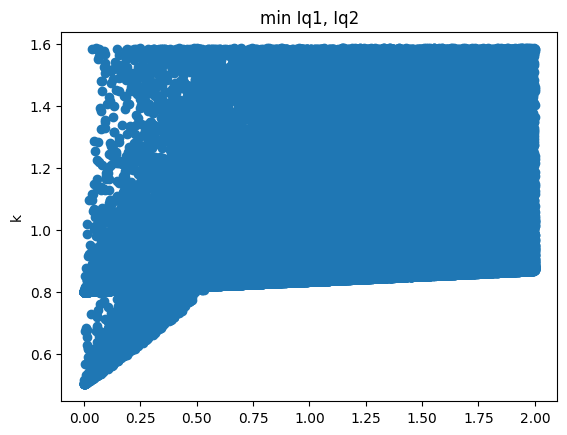

' \nAlgorithm for calculation of the k-coefficient which is parallel_coefficient within the branches:\n\n1. calculate the p-coefficients for each branch and for each source \n- compute with the electrical equivalent circuit with impedances of 1 Ohm for each branch\n-> return a dict\n {"branch1":{"source1":0.5, "source2":0.5}, "branch2":{...}}\n\n2. calculate the k-coefficient for each branch:\nAlgorithm:  \n- use for I_qi the maximum value of the frequency dict for the current sources e.g. {50:10, 250:1, 350:2} -> I_qi = 10\n- k = sum(p_i + I_qi) / (sum(I_qi))\n- check if sum(I_qi) is clos to 0, if yes raise an error\n- if not calculate the k-coefficient\n- where p_i is a coefficient as a complex number\n-> return a complex number\n\n3. write the complex number into the branch as a parallel_coefficient\n\nNote: I have to change the pydantic core model of the branches \n'

In [ ]:
#Helper function to analyze the behavior of the parallel_coefficient
""" 
k is element of complex numbers
k = sum(p_i + I_qi) / (sum(I_qi))
where p_i is a coefficient as a complex number with a magnitude 0...1
I_qi are all current sources with a given magnitude and phase
"""
def calc_k(p1, p2, Iq1, Iq2):
    k = (p1*Iq1 + p2*Iq2) / (Iq1 + Iq2)
    return k
#1 analyze different magnitudes with the same phase, Iq1 = 1 0° and Iq2 = 1 90°
#Iq1 = 1
#Iq2 = 1

p1 = 0.8
p2 = -0.5

# calc k for random values of p1 and p2, uniform distribution
k = []
Iqdelta = []
for _ in range(100000):
    Iq1 = np.random.uniform(0, 20) * (1+1j)
    Iq2 = np.random.uniform(0, 2) * -1
    k.append(calc_k(p1, p2, Iq1, Iq2))
    Iqdelta.append(min(abs(Iq1), abs(Iq2)))


import matplotlib.pyplot as plt
plt.plot(Iqdelta, np.abs(k), 'o')
plt.ylabel('k')
plt.title('min Iq1, Iq2')
plt.show()

#RESULT: k-coefficient as complex numbers can be used, but it should be checked if the error is acceptable (large values of k if Iq1 + Iq2 --> 0)
#check the sum of all Iq if they are close to 0 raise an error


""" 
Algorithm for calculation of the k-coefficient which is parallel_coefficient within the branches:

1. calculate the p-coefficients for each branch and for each source 
- compute with the electrical equivalent circuit with impedances of 1 Ohm for each branch
-> return a dict
 {"branch1":{"source1":0.5, "source2":0.5}, "branch2":{...}}

2. calculate the k-coefficient for each branch:
Algorithm:  
- use for I_qi the maximum value of the frequency dict for the current sources e.g. {50:10, 250:1, 350:2} -> I_qi = 10
- k = sum(p_i * I_qi) / (sum(I_qi))
- check if sum(I_qi) is clos to 0, if yes raise an error
- if not calculate the k-coefficient
- where p_i is a coefficient as a complex number
-> return a complex number

3. write the complex number into the branch as a parallel_coefficient

Note: I have to change the pydantic core model of the branches 
"""